In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
import pickle

%matplotlib inline

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/banksim1/bsNET140513_032310.csv
/kaggle/input/banksim1/bs140513_032310.csv


In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
df = pd.read_csv('/kaggle/input/banksim1/bs140513_032310.csv')

In [4]:
df['step'] = 1577836800 + df['step'] * 3600 * 24
df['step'] = pd.to_datetime(df['step'], unit='s')

In [5]:
df.columns

Index(['step', 'customer', 'age', 'gender', 'zipcodeOri', 'merchant',
       'zipMerchant', 'category', 'amount', 'fraud'],
      dtype='object')

In [6]:
df

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,2020-01-01,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,2020-01-01,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,2020-01-01,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,2020-01-01,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,2020-01-01,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0
...,...,...,...,...,...,...,...,...,...,...
594638,2020-06-28,'C1753498738','3','F','28007','M1823072687','28007','es_transportation',20.53,0
594639,2020-06-28,'C650108285','4','F','28007','M1823072687','28007','es_transportation',50.73,0
594640,2020-06-28,'C123623130','2','F','28007','M349281107','28007','es_fashion',22.44,0
594641,2020-06-28,'C1499363341','5','M','28007','M1823072687','28007','es_transportation',14.46,0


In [7]:
print('No. of fraud transactions: {}, No. of non-fraud transactions: {}'.format((df.fraud == 1).sum(), (df.fraud == 0).sum()))

No. of fraud transactions: 7200, No. of non-fraud transactions: 587443


In [8]:
df.loc[df.fraud == 1,'age'].value_counts()

'2'    2344
'3'    1755
'4'    1410
'1'     689
'5'     686
'6'     261
'0'      48
'U'       7
Name: age, dtype: int64

In [9]:
df.loc[df.fraud == 1,'gender'].value_counts()

'F'    4758
'M'    2435
'E'       7
Name: gender, dtype: int64

In [10]:
df.loc[df.fraud == 1,'category'].value_counts()

'es_sportsandtoys'         1982
'es_health'                1696
'es_wellnessandbeauty'      718
'es_travel'                 578
'es_hotelservices'          548
'es_leisure'                474
'es_home'                   302
'es_hyper'                  280
'es_otherservices'          228
'es_tech'                   158
'es_barsandrestaurants'     120
'es_fashion'                116
Name: category, dtype: int64

In [11]:
print('Min, Max amount of fraud transactions {}, {}'.format(df.loc[df.fraud == 1].amount.min(), df.loc[df.fraud == 1].amount.max()))
print('Min, Max amount of genuine transactions {}, {}'.format(df.loc[df.fraud == 0].amount.min(), df.loc[df.fraud == 0].amount.max()))

Min, Max amount of fraud transactions 0.03, 8329.96
Min, Max amount of genuine transactions 0.0, 2144.86


In [12]:
def last1DayTransactionCount(x):
    temp = pd.Series(x.index, index = x.step, name='count_1_day').sort_index()
    count_1_day = temp.rolling('1d').count() - 1
    count_1_day.index = temp.values
    x['count_1_day'] = count_1_day.reindex(x.index)
    return x
def last7DaysTransactionCount(x):
    temp = pd.Series(x.index, index = x.step, name='count_7_days').sort_index()
    count_7_days = temp.rolling('7d').count() - 1
    count_7_days.index = temp.values
    x['count_7_days'] = count_7_days.reindex(x.index)
    return x
def last30DaysTransactionCount(x):
    temp = pd.Series(x.index, index = x.step, name='count_30_days').sort_index()
    count_30_days = temp.rolling('30d').count() - 1
    count_30_days.index = temp.values
    x['count_30_days'] = count_30_days.reindex(x.index)
    return x

In [13]:
df = df.groupby('customer').apply(last1DayTransactionCount)
df = df.groupby('customer').apply(last7DaysTransactionCount)
df = df.groupby('customer').apply(last30DaysTransactionCount)

In [14]:
def last1DayCustMerchTransactionCount(x):
    temp = pd.Series(x.index, index = x.step, name='count_1_day').sort_index()
    count_1_day = temp.rolling('1d').count() - 1
    count_1_day.index = temp.values
    x['count_cust_merch_1_day'] = count_1_day.reindex(x.index)
    return x
def last7DaysCustMerchTransactionCount(x):
    temp = pd.Series(x.index, index = x.step, name='count_7_days').sort_index()
    count_7_days = temp.rolling('7d').count() - 1
    count_7_days.index = temp.values
    x['count_cust_merch_7_days'] = count_7_days.reindex(x.index)
    return x
def last30DaysCustMerchTransactionCount(x):
    temp = pd.Series(x.index, index = x.step, name='count_30_days').sort_index()
    count_30_days = temp.rolling('30d').count() - 1
    count_30_days.index = temp.values
    x['count_cust_merch_30_days'] = count_30_days.reindex(x.index)
    return x

In [15]:
df = df.groupby(['customer','merchant']).apply(last1DayCustMerchTransactionCount)
df = df.groupby(['customer','merchant']).apply(last7DaysCustMerchTransactionCount)
df = df.groupby(['customer','merchant']).apply(last30DaysCustMerchTransactionCount)

In [16]:
df

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud,count_1_day,count_7_days,count_30_days,count_cust_merch_1_day,count_cust_merch_7_days,count_cust_merch_30_days
0,2020-01-01,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020-01-01,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-01-01,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-01-01,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020-01-01,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594638,2020-06-28,'C1753498738','3','F','28007','M1823072687','28007','es_transportation',20.53,0,0.0,6.0,30.0,0.0,6.0,29.0
594639,2020-06-28,'C650108285','4','F','28007','M1823072687','28007','es_transportation',50.73,0,0.0,6.0,29.0,0.0,6.0,25.0
594640,2020-06-28,'C123623130','2','F','28007','M349281107','28007','es_fashion',22.44,0,0.0,5.0,29.0,0.0,0.0,0.0
594641,2020-06-28,'C1499363341','5','M','28007','M1823072687','28007','es_transportation',14.46,0,0.0,6.0,29.0,0.0,4.0,24.0


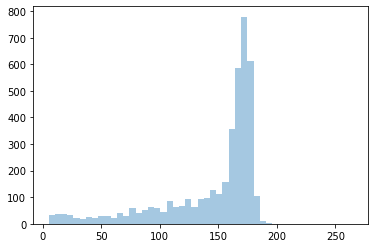

In [17]:
cust = df.groupby('customer').apply(lambda df:len(df))
sns.distplot(cust.values,kde=False)

In [18]:
df.count_1_day[df.fraud == 1].value_counts() / len(df.count_1_day[df.fraud == 1])

0.0    0.697639
1.0    0.261389
2.0    0.032083
3.0    0.007222
4.0    0.001667
Name: count_1_day, dtype: float64

In [19]:
df.count_1_day[df.fraud == 0].value_counts() / len(df.count_1_day[df.fraud == 0])

0.0    0.965387
1.0    0.032495
2.0    0.001782
3.0    0.000330
4.0    0.000005
Name: count_1_day, dtype: float64

# Model Training

In [20]:
data = df.drop(['customer','merchant','zipcodeOri','zipMerchant','step'],axis=1)

In [21]:
cat_cols = ['age', 'gender', 'category']
enc = LabelEncoder()
for col in cat_cols:
    data[col] = enc.fit_transform(data[col])

In [22]:
data

,age,gender,category,amount,fraud,count_1_day,count_7_days,count_30_days,count_cust_merch_1_day,count_cust_merch_7_days,count_cust_merch_30_days
0,4,2,12,4.55,0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2,12,39.68,0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,1,12,26.89,0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2,12,17.25,0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2,12,35.72,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
594638,3,1,12,20.53,0,0.0,6.0,30.0,0.0,6.0,29.0
594639,4,1,12,50.73,0,0.0,6.0,29.0,0.0,6.0,25.0
594640,2,1,2,22.44,0,0.0,5.0,29.0,0.0,0.0,0.0
594641,5,2,12,14.46,0,0.0,6.0,29.0,0.0,4.0,24.0


## Standard Data without Feature Engineering

In [23]:
Y = data['fraud']
X = data.drop(['fraud','count_1_day','count_7_days','count_30_days','count_cust_merch_1_day','count_cust_merch_7_days','count_cust_merch_30_days'],axis=1)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y,test_size=0.2, random_state = 1)

weights = (Y == 0).sum() / (Y == 1).sum()
clf = XGBClassifier(max_depth=3,scale_pos_weights=weights,n_jobs=4)
clf.fit(Xtrain,Ytrain)

print('AUPRC = {}'.format(average_precision_score(Ytest, clf.predict_proba(Xtest)[:,1])))

[12:06:07] WARNING: /workspace/src/learner.cc:480: 
Parameters: { scale_pos_weights } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


AUPRC = 0.8330948904251961


## Feature Engineered Data

In [24]:
Y = data['fraud']
X = data.drop('fraud',axis=1)

Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y,test_size=0.2, random_state = 1)

weights = (Y == 0).sum() / (Y == 1).sum()
clf = XGBClassifier(max_depth=3,scale_pos_weights=weights,n_jobs=4)
clf.fit(Xtrain,Ytrain)

print('AUPRC = {}'.format(average_precision_score(Ytest, clf.predict_proba(Xtest)[:,1])))

[12:06:15] WARNING: /workspace/src/learner.cc:480: 
Parameters: { scale_pos_weights } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


AUPRC = 0.8811960189034069


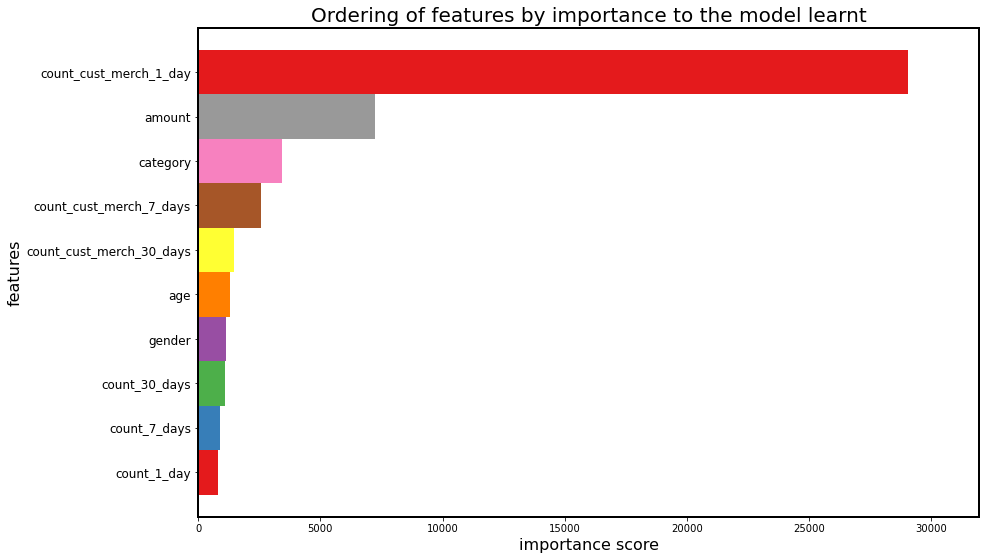

In [25]:
fig = plt.figure(figsize = (14, 9))
ax = fig.add_subplot(111)

colours = plt.cm.Set1(np.linspace(0, 1, 9))

ax = plot_importance(clf, height = 1, color = colours, grid = False, \
                     show_values = False, importance_type = 'cover', ax = ax);
for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(2)
        
ax.set_xlabel('importance score', size = 16);
ax.set_ylabel('features', size = 16);
ax.set_yticklabels(ax.get_yticklabels(), size = 12);
ax.set_title('Ordering of features by importance to the model learnt', size = 20);

In [26]:
data

,age,gender,category,amount,fraud,count_1_day,count_7_days,count_30_days,count_cust_merch_1_day,count_cust_merch_7_days,count_cust_merch_30_days
0,4,2,12,4.55,0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2,12,39.68,0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,1,12,26.89,0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2,12,17.25,0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2,12,35.72,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
594638,3,1,12,20.53,0,0.0,6.0,30.0,0.0,6.0,29.0
594639,4,1,12,50.73,0,0.0,6.0,29.0,0.0,6.0,25.0
594640,2,1,2,22.44,0,0.0,5.0,29.0,0.0,0.0,0.0
594641,5,2,12,14.46,0,0.0,6.0,29.0,0.0,4.0,24.0


In [27]:
pickle.dump(clf,open('XGB-BankSim.pkl','wb'))

In [28]:
clf.score(Xtest.loc[Ytest==1],Ytest.loc[Ytest==1])

0.7075283144570287